In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [5]:
train_df = pd.read_csv(
    "../data/processed/train_features.csv"
)

exclude_cols = [
    "unit",
    "cycle",
    "RUL",
    "setting_1",
    "setting_2",
    "setting_3"
]

feature_cols = [
    col for col in train_df.columns
    if col not in exclude_cols
]

train_df = train_df.sort_values(
    ["unit", "cycle"]
).reset_index(drop=True)


exclude_cols = [
    "unit",
    "cycle",
    "RUL",
    "setting_1",
    "setting_2",
    "setting_3"
]

feature_cols = [
    col for col in train_df.columns
    if col not in exclude_cols
]



units = train_df["unit"].unique()

print("Number of engines:", len(units))


train_units, val_units = train_test_split(
    units,
    test_size=0.2,
    random_state=42
)


train_data = train_df[
    train_df["unit"].isin(train_units)
].copy()

val_data = train_df[
    train_df["unit"].isin(val_units)
].copy()



Number of engines: 100


In [6]:
scaler = StandardScaler()

train_data_scaled = train_data.copy()
val_data_scaled = val_data.copy()

train_data_scaled[feature_cols] = scaler.fit_transform(
    train_data[feature_cols]
)

val_data_scaled[feature_cols] = scaler.transform(
    val_data[feature_cols]
)

joblib.dump(
    scaler,
    "../models/lstm_feature_scaler.joblib"
)

['../models/lstm_feature_scaler.joblib']

In [10]:
sequence_length = 30
def create_sequences(df, feature_cols, sequence_length=30):
    X = []
    y = []

    for unit_id in df["unit"].unique():

        unit_df = df[df["unit"] == unit_id].sort_values("cycle")

        feature_values = unit_df[feature_cols].values
        rul_values = unit_df["RUL"].values

        for i in range(len(unit_df) - sequence_length + 1):

            X.append(
                feature_values[i:i + sequence_length]
            )

            y.append(
                rul_values[i + sequence_length - 1]
            )

    return np.array(X), np.array(y)

In [12]:
X_train, y_train = create_sequences(
    train_data_scaled,
    feature_cols,
    sequence_length
)

X_val, y_val = create_sequences(
    val_data_scaled,
    feature_cols,
    sequence_length
)


print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (14241, 30, 112)
y_train: (14241,)
X_val: (3490, 30, 112)
y_val: (3490,)


In [13]:
X_train[0]

array([[-1.58119086, -1.09266247, -1.96301407, ..., -0.01616434,
         0.01798132,  0.01768769],
       [-1.72172228, -0.56515529, -1.75666396, ...,  0.73368889,
         0.86437258, -0.57058055],
       [-2.26377202, -0.35645308, -1.10638223, ..., -0.76601757,
         0.37064435,  0.21181621],
       ...,
       [-1.28005212, -1.46076717, -1.27480855, ..., -1.5158708 ,
        -0.05255128,  0.15887207],
       [-1.19974845, -1.10252242, -1.20453797, ..., -0.01616434,
         0.15904653, -0.15408664],
       [-1.80202594, -0.02778817, -1.54027518, ...,  0.73368889,
         0.93490519, -0.29291794]], shape=(30, 112))

In [14]:
model_1 = Sequential([
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),

    Dropout(0.2),

    LSTM(32),

    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(1)
])

model_1.summary()

model_1.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)



early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

C:\Users\Malak\miniconda3\envs\predictive-maintenance\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 64)              │          45,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 58,273 (227.63 KB)

 Trainable params: 58,273 (227.63 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history_1 = model_1.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - loss: 10316.0879 - mae: 81.0501 - val_loss: 6236.0698 - val_mae: 59.6901 - learning_rate: 0.0010
Epoch 2/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 4434.8857 - mae: 44.8459 - val_loss: 1863.9904 - val_mae: 28.5353 - learning_rate: 0.0010
Epoch 3/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 1688.3866 - mae: 24.4592 - val_loss: 854.9214 - val_mae: 20.0252 - learning_rate: 0.0010
Epoch 4/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 939.8361 - mae: 17.8563 - val_loss: 776.3541 - val_mae: 19.8071 - learning_rate: 0.0010
Epoch 5/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 653.5820 - mae: 15.0111 - val_loss: 674.0302 - val_mae: 17.7509 - learning_rate: 0.0010
Epoch 6/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 456.9510 - mae: 12.6904 - val_loss: 698.5453 - val_mae: 18.5894 - learning_rate: 0.0010
Epoch 7/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 330.2577 - mae: 11.1766 - val_loss: 67

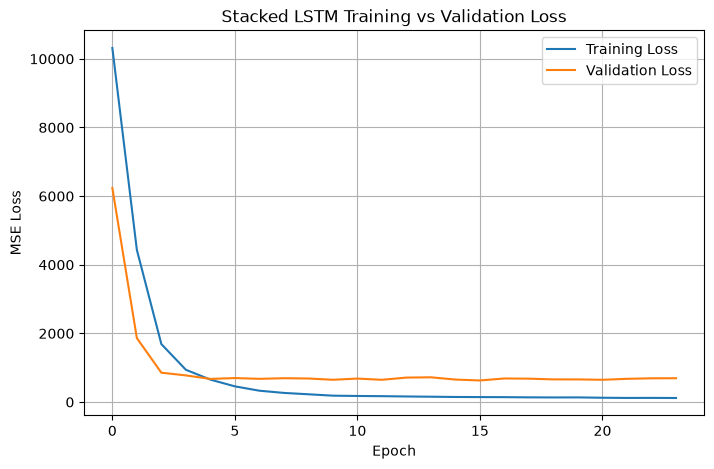

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(history_1.history["loss"], label="Training Loss")
plt.plot(history_1.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Stacked LSTM Training vs Validation Loss")

plt.legend()
plt.grid(True)
plt.savefig(
    "../results/figures/feature_engineered/lstm/loss.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

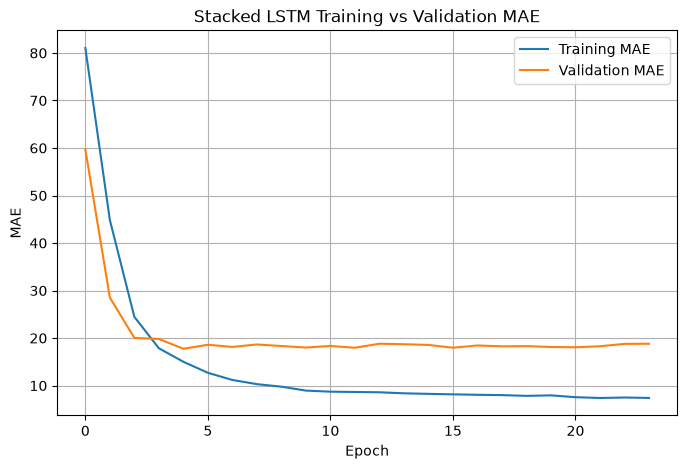

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(history_1.history["mae"], label="Training MAE")
plt.plot(history_1.history["val_mae"], label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Stacked LSTM Training vs Validation MAE")

plt.legend()
plt.grid(True)
plt.savefig(
    "../results/figures/feature_engineered/lstm/mae.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [19]:
y_pred = model_1.predict(X_val).flatten()

110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


In [20]:
print(y_pred[:10])
print(y_val[:10])

[151.52196 145.32913 152.43849 158.85524 152.15575 157.06483 160.61661
 169.1338  186.98866 191.06895]
[162 161 160 159 158 157 156 155 154 153]


In [21]:
mae = mean_absolute_error(y_val, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_val, y_pred)
)

r2 = r2_score(y_val, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 17.9683
RMSE: 25.0728
R²: 0.8147


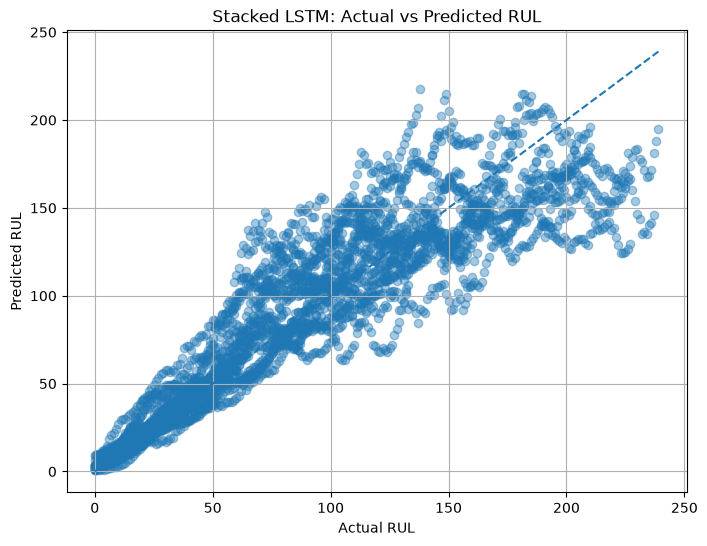

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_val,
    y_pred,
    alpha=0.4
)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Stacked LSTM: Actual vs Predicted RUL")

plt.grid(True)

plt.savefig(
    "../results/figures/feature_engineered/lstm/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
model_1.save(
    "../models/stacked_lstm_rul.keras"
)

In [24]:
metrics_df = pd.DataFrame({
    "Model": ["Stacked LSTM"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2]
})

metrics_df.to_csv(
    "../results/stacked_lstm_metrics.csv",
    index=False
)